# Chapter 1 — Exploratory Data Analysis

**Mata Kuliah:** Deep Learning  
**Buku:** Practical Statistics for Data Scientists  
**Chapter:** 1 — Exploratory Data Analysis

## Tujuan

Pada chapter ini dilakukan reproduksi kode Python dan pembahasan
konsep Exploratory Data Analysis (EDA).

Pembahasan meliputi:
1. Struktur data
2. Ukuran pemusatan data
3. Ukuran variabilitas data
4. Distribusi data
5. Data biner dan kategorikal
6. Korelasi
7. Eksplorasi hubungan beberapa variabel

# 1. Exploratory Data Analysis

Exploratory Data Analysis (EDA) atau Analisis Data Eksploratif adalah
proses untuk mengeksplorasi dan memahami data sebelum melakukan analisis
statistik atau membangun model.

EDA digunakan untuk mengetahui:

- bagaimana struktur data,
- nilai tipikal dari suatu variabel,
- seberapa besar penyebaran data,
- bagaimana distribusi data,
- hubungan antarvariabel,
- serta adanya nilai yang tidak biasa atau ekstrem.

Dalam EDA, data dianalisis menggunakan kombinasi antara perhitungan
statistik dan visualisasi.

## IMPORT LIBRARY


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean
from statsmodels import robust

%matplotlib inline

sns.set_theme(style="whitegrid")

## Membaca Dataset


In [7]:
state = pd.read_csv("/content/sample_data/state.csv")

state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


## MEMAHAMI DATASET

head() digunakan untuk melihat beberapa baris pertama dataset.

In [11]:
state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


Mengetahui ukuran dataset

In [8]:
state.shape

(50, 4)

Melihat informasi dataset

In [9]:
state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


Statistik deskriptif

In [10]:
state.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


# 2. Estimates of Location

Estimates of Location digunakan untuk mengetahui nilai yang mewakili
pusat atau lokasi data.

Beberapa ukuran yang digunakan adalah:

- Mean
- Weighted Mean
- Median
- Weighted Median
- Trimmed Mean

Mean merupakan ukuran yang umum digunakan, tetapi dapat dipengaruhi
oleh nilai ekstrem atau outlier.

Median dan trimmed mean lebih tahan terhadap pengaruh nilai ekstrem.

## 2.1 Mean

Mean atau rata-rata diperoleh dengan menjumlahkan seluruh nilai
kemudian membaginya dengan jumlah observasi.

Pada contoh ini, mean digunakan untuk mengetahui rata-rata populasi
negara bagian.

In [12]:
state["Population"].mean()

np.float64(6162876.3)

## 2.2 Trimmed Mean

Trimmed mean adalah rata-rata yang dihitung setelah sejumlah nilai
ekstrem pada bagian bawah dan bagian atas data dibuang.

Pada contoh ini digunakan trimming sebesar 10%.

Artinya, 10% data dengan nilai terendah dan 10% data dengan nilai
tertinggi tidak digunakan dalam perhitungan.

In [13]:
trim_mean(state["Population"], 0.1)

np.float64(4783697.125)

## 2.3 Median

Median adalah nilai tengah setelah data diurutkan.

Median lebih tahan terhadap pengaruh nilai ekstrem dibandingkan mean.
Oleh karena itu, median sering digunakan ketika data memiliki outlier.

In [14]:
state["Population"].median()

4436369.5

### Bandingkan ketiganya

In [15]:
mean_population = state["Population"].mean()
trimmed_mean_population = trim_mean(state["Population"], 0.1)
median_population = state["Population"].median()

print("Mean          :", mean_population)
print("Trimmed Mean  :", trimmed_mean_population)
print("Median        :", median_population)

Mean          : 6162876.3
Trimmed Mean  : 4783697.125
Median        : 4436369.5


### Interpretasi

Hasil perhitungan menunjukkan bahwa mean, trimmed mean, dan median
menghasilkan nilai yang berbeda.

Perbedaan tersebut menunjukkan bahwa distribusi populasi negara bagian
tidak sepenuhnya simetris. Beberapa negara bagian memiliki populasi
yang jauh lebih besar dibandingkan negara bagian lainnya.

Nilai ekstrem tersebut dapat meningkatkan nilai mean.

Trimmed mean mengurangi pengaruh nilai ekstrem karena sebagian data
terendah dan tertinggi tidak digunakan dalam perhitungan.

Median hanya bergantung pada posisi nilai tengah sehingga lebih tahan
terhadap pengaruh outlier.

## 2.4 Weighted Mean

Weighted mean atau rata-rata berbobot adalah rata-rata yang memberikan
bobot yang berbeda pada setiap nilai.

Pada dataset `state`, setiap negara bagian memiliki jumlah penduduk yang
berbeda. Jika kita ingin menghitung rata-rata Murder Rate untuk seluruh
penduduk, setiap negara bagian tidak dapat dianggap memiliki bobot yang
sama.

Jumlah penduduk digunakan sebagai bobot (`weight`).

Rumus weighted mean:

Weighted Mean = Σ(x × w) / Σw

Keterangan:
- x = nilai yang ingin dihitung rata-ratanya
- w = bobot dari setiap nilai

Hitung Weighted Mean

In [16]:
weighted_mean = np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)

weighted_mean

np.float64(4.445833981123393)

### Interpretasi Weighted Mean

Weighted mean Murder Rate adalah sekitar 4,45.

Perhitungan ini memberikan bobot yang lebih besar kepada negara bagian
dengan jumlah penduduk yang lebih besar. Oleh karena itu, hasilnya lebih
merepresentasikan rata-rata Murder Rate berdasarkan jumlah penduduk,
dibandingkan jika setiap negara bagian dianggap memiliki bobot yang sama.

WEIGHTED MEDIAN

Install library

In [17]:
!pip install wquantiles

In [18]:
import wquantiles

## 2.5 Weighted Median

Weighted median merupakan median yang memperhitungkan bobot setiap
observasi.

Berbeda dengan median biasa yang mencari nilai tengah berdasarkan jumlah
observasi, weighted median mempertimbangkan total bobot dari data.

Pada contoh ini:
- `Murder.Rate` menjadi nilai yang dicari mediannya.
- `Population` menjadi bobot.

Dengan demikian, negara bagian dengan populasi yang lebih besar memiliki
pengaruh lebih besar terhadap posisi median.

Hitung Weighted Median

In [19]:
weighted_median = wquantiles.median(
    state["Murder.Rate"],
    weights=state["Population"]
)

weighted_median

np.float64(4.4)

### Interpretasi Weighted Median

Weighted median Murder Rate adalah sekitar 4,4.

Nilai weighted median hampir sama dengan weighted mean yang sebelumnya
diperoleh, yaitu sekitar 4,45.

Hal ini menunjukkan bahwa ketika jumlah penduduk digunakan sebagai bobot,
kedua ukuran tersebut memberikan gambaran pusat data yang relatif sama
pada dataset ini.

## 2.6 Ringkasan Estimates of Location

Pada bagian ini telah digunakan beberapa ukuran untuk mengetahui pusat
atau nilai tipikal dari data.

| Ukuran | Fungsi |
|---|---|
| Mean | Menghitung rata-rata biasa |
| Trimmed Mean | Rata-rata setelah mengurangi nilai ekstrem |
| Median | Menentukan nilai tengah |
| Weighted Mean | Rata-rata dengan mempertimbangkan bobot |
| Weighted Median | Median dengan mempertimbangkan bobot |

Mean mudah digunakan tetapi sensitif terhadap nilai ekstrem.

Median dan trimmed mean lebih tahan terhadap outlier.

Weighted mean dan weighted median digunakan ketika setiap observasi
memiliki tingkat kepentingan atau bobot yang berbeda.

# 3. Estimates of Variability

Variabilitas atau dispersion digunakan untuk mengetahui seberapa jauh
nilai-nilai dalam suatu dataset tersebar dari nilai pusatnya.

Jika ukuran lokasi menjawab pertanyaan:

"Di mana pusat data?"

Maka ukuran variabilitas menjawab:

"Seberapa tersebar data tersebut?"

Beberapa ukuran variabilitas yang digunakan dalam chapter ini adalah:

- Deviation
- Variance
- Standard Deviation
- Mean Absolute Deviation
- Median Absolute Deviation (MAD)
- Range
- Percentile
- Interquartile Range (IQR)

## 3.1 Deviation

Deviation atau penyimpangan adalah selisih antara suatu nilai observasi
dengan nilai pusat data.

Secara sederhana:

Deviation = nilai observasi - nilai rata-rata

Contohnya, jika rata-rata populasi adalah 5 juta dan suatu negara bagian
memiliki populasi 6 juta, maka deviation-nya adalah:

6 juta - 5 juta = 1 juta

Nilai deviation positif berarti observasi berada di atas rata-rata,
sedangkan nilai negatif berarti observasi berada di bawah rata-rata.

Hitung Deviation

In [21]:
population_mean = state["Population"].mean()

deviation = state["Population"] - population_mean

deviation.head()

,Population
0,-1383140.3
1,-5452645.3
2,229140.7
3,-3246958.3
4,31091079.7


## 3.2 Variance

Variance atau varians digunakan untuk mengukur tingkat penyebaran data
berdasarkan kuadrat dari deviation.

Jika deviation langsung dijumlahkan, nilai positif dan negatif dapat
saling menghilangkan.

Oleh karena itu, deviation dikuadratkan terlebih dahulu.

Secara konsep:

Variance = jumlah kuadrat deviation / (n - 1)

Semakin besar variance, semakin besar penyebaran data dari nilai
pusatnya.

Hitung Variance

In [22]:
state["Population"].var()

46898327373394.445

## 3.3 Standard Deviation

Standard deviation atau standar deviasi adalah akar kuadrat dari
variance.

Standard deviation merupakan salah satu ukuran variabilitas yang
paling sering digunakan.

Keuntungan standard deviation dibandingkan variance adalah satuannya
sama dengan data asli.

Pada dataset ini, data Population memiliki satuan jumlah penduduk,
sehingga standard deviation juga berada dalam satuan jumlah penduduk.

Hitung Standard Deviation

In [23]:
state["Population"].std()

6848235.347401142

### Interpretasi

Standard deviation populasi negara bagian sekitar 6,85 juta.

Artinya, data Population memiliki penyebaran yang cukup besar terhadap
nilai rata-ratanya.

Perlu diperhatikan bahwa standard deviation sensitif terhadap nilai
ekstrem. Negara bagian dengan populasi yang sangat besar dapat
meningkatkan nilai standard deviation.

## 3.4 Mean Absolute Deviation

Mean Absolute Deviation (MAD) adalah rata-rata dari nilai absolut
deviation terhadap mean.

Nilai absolut digunakan agar deviation negatif dan positif tidak saling
menghilangkan.

Secara konsep:

MAD = rata-rata(|nilai - mean|)

Hitung Mean Absolute Deviation

In [24]:
mean_absolute_deviation = (
    state["Population"] - state["Population"].mean()
).abs().mean()

mean_absolute_deviation

np.float64(4450933.356000001)

## 3.5 Median Absolute Deviation (MAD)

Median Absolute Deviation dari median merupakan ukuran variabilitas
yang lebih tahan terhadap pengaruh outlier dibandingkan standard
deviation.

Cara menghitungnya:

1. Tentukan median data.
2. Hitung selisih absolut setiap nilai terhadap median.
3. Cari median dari seluruh selisih absolut tersebut.

Ukuran ini berguna ketika dataset memiliki nilai ekstrem.

Hitung MAD

In [25]:
robust.mad(state["Population"])

np.float64(3849876.1459979336)

### Perbandingan Standard Deviation dan MAD

Pada dataset ini:

- Standard deviation ≈ 6,85 juta
- Median Absolute Deviation ≈ 3,85 juta

Standard deviation menghasilkan nilai yang lebih besar dibandingkan
MAD.

Salah satu alasannya adalah standard deviation lebih sensitif terhadap
nilai ekstrem, sedangkan MAD merupakan ukuran yang lebih robust.

## 3.6 Range

Range adalah selisih antara nilai terbesar dan nilai terkecil dalam
suatu dataset.

Rumus:

Range = nilai maksimum - nilai minimum

Range merupakan ukuran penyebaran yang sederhana, tetapi sangat
dipengaruhi oleh nilai ekstrem karena hanya menggunakan nilai minimum
dan maksimum.

In [26]:
population_range = (
    state["Population"].max() -
    state["Population"].min()
)

population_range

36690330

Tabel perbandingan

In [27]:
variability_summary = pd.DataFrame({
    "Ukuran": [
        "Variance",
        "Standard Deviation",
        "Mean Absolute Deviation",
        "Median Absolute Deviation",
        "Range"
    ],
    "Nilai": [
        state["Population"].var(),
        state["Population"].std(),
        mean_absolute_deviation,
        robust.mad(state["Population"]),
        population_range
    ]
})

variability_summary

,Ukuran,Nilai
0,Variance,4.689833e+13
1,Standard Deviation,6.848235e+06
2,Mean Absolute Deviation,4.450933e+06
3,Median Absolute Deviation,3.849876e+06
4,Range,3.669033e+07


### Interpretasi Ukuran Variabilitas

Berbagai ukuran variabilitas memberikan cara yang berbeda untuk
menggambarkan penyebaran data.

Variance menggunakan kuadrat deviation sehingga nilainya memiliki
satuan kuadrat dari data asli.

Standard deviation merupakan akar dari variance sehingga satuannya
kembali sama dengan data asli.

Mean Absolute Deviation menggunakan nilai absolut deviation.

Median Absolute Deviation lebih robust terhadap nilai ekstrem.

Range merupakan ukuran yang paling sederhana karena hanya menggunakan
nilai minimum dan maksimum.

Pada dataset Population, standard deviation lebih besar dibandingkan
MAD karena standard deviation lebih sensitif terhadap nilai ekstrem.

# 4. Estimates Based on Percentiles

Percentile adalah nilai yang menunjukkan posisi suatu data dalam
distribusi.

P-th percentile adalah nilai di mana setidaknya P persen data berada
pada atau di bawah nilai tersebut.

Contoh:

- Percentile ke-25 berarti sekitar 25% data berada pada atau di bawah
  nilai tersebut.
- Percentile ke-50 sama dengan median.
- Percentile ke-75 berarti sekitar 75% data berada pada atau di bawah
  nilai tersebut.

Percentile juga dapat digunakan untuk mengukur penyebaran data.

## 4.1 Percentile Murder Rate

menghitung beberapa percentile dari Murder Rate, yaitu:

- 5%
- 25%
- 50%
- 75%
- 95%

Hal ini digunakan untuk melihat bagaimana Murder Rate tersebar
di antara negara bagian.

In [28]:
state["Murder.Rate"].quantile([0.05, 0.25, 0.50, 0.75, 0.95])

,Murder.Rate
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


### Interpretasi Percentile

Hasil percentile menunjukkan bahwa:

- Percentile 5% sekitar 1,60
- Percentile 25% sekitar 2,42
- Percentile 50% sekitar 4,00
- Percentile 75% sekitar 5,55
- Percentile 95% sekitar 6,51

Percentile ke-50 merupakan median. Jadi median Murder Rate adalah
sekitar 4 pembunuhan per 100.000 penduduk.

Rentang antara percentile ke-5 dan ke-95 juga menunjukkan bahwa
Murder Rate memiliki variasi yang cukup besar.

## 4.2 Interquartile Range (IQR)

Interquartile Range atau IQR adalah selisih antara percentile ke-75
dan percentile ke-25.

Rumus:

IQR = Q3 - Q1

Keterangan:

Q1 = percentile ke-25
Q3 = percentile ke-75

IQR menunjukkan penyebaran 50% data yang berada di bagian tengah
distribusi.

IQR lebih tahan terhadap outlier dibandingkan range karena tidak
menggunakan nilai minimum dan maksimum.

Hitung Q1 dan Q3

In [29]:
Q1 = state["Population"].quantile(0.25)
Q3 = state["Population"].quantile(0.75)

print("Q1 (25%) :", Q1)
print("Q3 (75%) :", Q3)

Q1 (25%) : 1833004.25
Q3 (75%) : 6680312.25


Hitung IQR

In [31]:
state["Population"].quantile(0.75) - state["Population"].quantile(0.25)

np.float64(4847308.0)

### Interpretasi IQR

IQR Population sekitar 4,85 juta.

Artinya, rentang antara percentile ke-25 dan percentile ke-75
mencakup 50% data bagian tengah.

IQR tidak menggunakan nilai minimum dan maksimum sehingga lebih
tidak sensitif terhadap outlier dibandingkan range.

## 4.3 Perbandingan Ukuran Variabilitas

Beberapa ukuran yang telah dipelajari memiliki karakteristik berbeda.

- Range menggunakan nilai minimum dan maksimum sehingga sangat sensitif
  terhadap outlier.
- Standard deviation juga sensitif terhadap outlier.
- MAD lebih robust terhadap nilai ekstrem.
- IQR hanya menggunakan percentile ke-25 dan ke-75 sehingga lebih tahan
  terhadap pengaruh nilai ekstrem.

Oleh karena itu, tidak ada satu ukuran yang selalu digunakan untuk
semua kondisi. Pemilihan ukuran perlu disesuaikan dengan karakteristik
data.

# 5. Boxplot

Boxplot adalah visualisasi yang digunakan untuk melihat distribusi data
secara ringkas.

Boxplot menunjukkan beberapa bagian penting:

- Q1 atau percentile ke-25
- Median atau percentile ke-50
- Q3 atau percentile ke-75
- IQR
- Whisker
- Potensi outlier

Bagian kotak menunjukkan rentang antara Q1 dan Q3.
Garis di dalam kotak menunjukkan median.

Dengan boxplot, distribusi dan nilai ekstrem dapat dilihat dengan cepat.

Membuat Boxplot

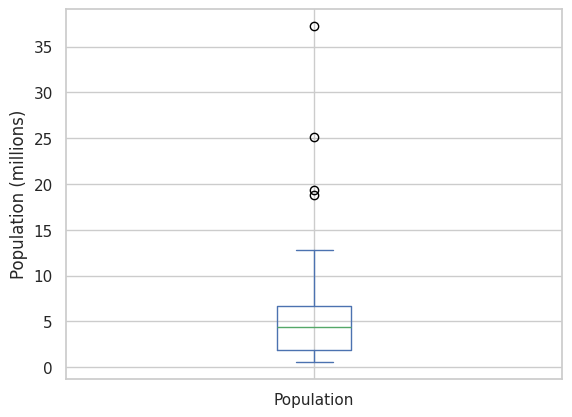

In [33]:
ax = (state["Population"] / 1_000_000).plot.box()

ax.set_ylabel("Population (millions)")
plt.show()

### 5.1 Interpretasi Boxplot

Boxplot Population menunjukkan bahwa distribusi populasi negara bagian
memiliki beberapa nilai ekstrem pada bagian atas.

Median populasi berada di sekitar 5 juta penduduk.

Sebagian besar negara bagian memiliki populasi yang berada dalam
rentang antara percentile ke-25 dan percentile ke-75.

Terdapat beberapa negara bagian dengan populasi yang jauh lebih besar
dibandingkan sebagian besar negara bagian lainnya. Nilai tersebut
terlihat sebagai titik yang berada di luar whisker.

Hal ini juga membantu menjelaskan mengapa mean dan standard deviation
cukup dipengaruhi oleh nilai ekstrem.

# 6. Exploring the Data Distribution

Sebelumnya kita sudah menghitung berbagai ukuran statistik seperti
mean, median, standard deviation, dan percentile.

Namun, satu angka saja belum cukup untuk mengetahui bentuk keseluruhan
distribusi data.

Pada bagian ini kita akan melihat distribusi data menggunakan:

- Frequency Table
- Histogram
- Density Plot

Frequency table digunakan untuk menghitung jumlah observasi yang berada
dalam interval tertentu.

## 6.1 Frequency Table

Frequency table membagi rentang nilai menjadi beberapa interval.

Setiap interval disebut sebagai bin.

Contohnya, jika kita membagi Population ke dalam beberapa kelompok,
kita dapat mengetahui berapa banyak negara bagian yang memiliki populasi
dalam setiap kelompok tersebut.

In [34]:
population = state["Population"]

breaks = np.linspace(
    population.min(),
    population.max(),
    11
)

breaks

array([  563626.,  4232659.,  7901692., 11570725., 15239758., 18908791.,
       22577824., 26246857., 29915890., 33584923., 37253956.])

Frequency table

In [36]:
frequency_table_df = pd.DataFrame({
    "Interval": frequency_table.index.astype(str),
    "Frekuensi": frequency_table.values
})

frequency_table_df

,Interval,Frekuensi
0,"(563625.999, 4232659.0]",24
1,"(4232659.0, 7901692.0]",14
2,"(7901692.0, 11570725.0]",6
3,"(11570725.0, 15239758.0]",2
4,"(15239758.0, 18908791.0]",1
5,"(18908791.0, 22577824.0]",1
6,"(22577824.0, 26246857.0]",1
7,"(26246857.0, 29915890.0]",0
8,"(29915890.0, 33584923.0]",0
9,"(33584923.0, 37253956.0]",1


## 6.2 Interpretasi Frequency Table

Frequency table menunjukkan jumlah negara bagian yang berada pada
masing-masing interval Population.

Interval dengan frekuensi tinggi menunjukkan bahwa terdapat banyak
negara bagian dengan jumlah penduduk pada rentang tersebut.

Sebaliknya, interval dengan frekuensi rendah menunjukkan bahwa hanya
sedikit negara bagian yang memiliki jumlah penduduk pada rentang
tersebut.

Frequency table membantu kita melihat distribusi data secara lebih
terstruktur sebelum divisualisasikan menggunakan histogram.

# 7. Histogram

Histogram adalah visualisasi dari frequency table.

Pada histogram:

- Sumbu X menunjukkan nilai atau interval data.
- Sumbu Y menunjukkan jumlah atau frekuensi data.
- Data dibagi menjadi beberapa bin.
- Lebar setiap bin biasanya dibuat sama.

Histogram membantu kita melihat bentuk distribusi data secara cepat.

Histogram Population

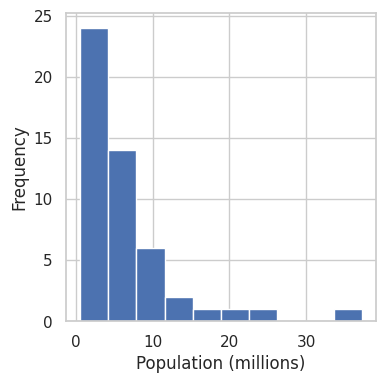

In [37]:
ax = (state["Population"] / 1_000_000).plot.hist(figsize=(4, 4))

ax.set_xlabel("Population (millions)")
ax.set_ylabel("Frequency")

plt.show()

### 7.1 Interpretasi Histogram Population

Histogram menunjukkan bahwa distribusi Population tidak simetris.

Sebagian besar negara bagian berada pada rentang populasi yang relatif
lebih rendah, sedangkan hanya beberapa negara bagian yang memiliki
populasi sangat besar.

Hal tersebut menyebabkan distribusi memiliki ekor ke arah kanan.

Beberapa nilai populasi yang sangat besar juga terlihat sebagai nilai
ekstrem dalam distribusi.

### 7.2 MENGUBAH JUMLAH BIN

10 BIN


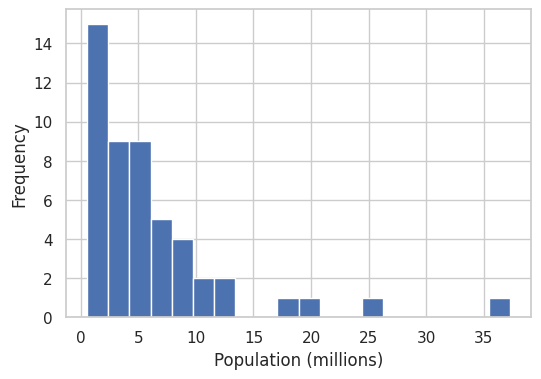

In [38]:
ax = (state["Population"] / 1_000_000).plot.hist(
    bins=20,
    figsize=(6, 4)
)

ax.set_xlabel("Population (millions)")
ax.set_ylabel("Frequency")

plt.show()

5 BIN

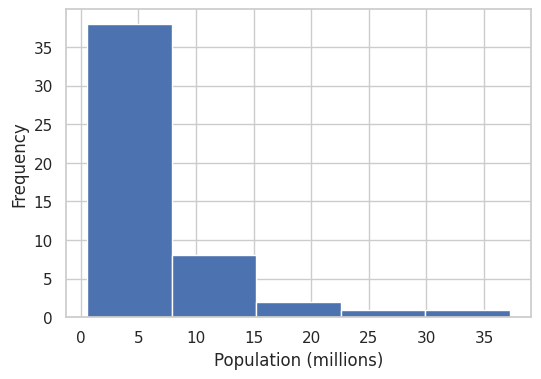

In [39]:
ax = (state["Population"] / 1_000_000).plot.hist(
    bins=5,
    figsize=(6, 4)
)

ax.set_xlabel("Population (millions)")
ax.set_ylabel("Frequency")

plt.show()

### 7.3 Pengaruh Jumlah Bin

Jumlah bin memengaruhi detail yang terlihat pada histogram.

Jika jumlah bin terlalu sedikit, beberapa pola penting dalam data dapat
tersembunyi karena data terlalu banyak digabungkan.

Jika jumlah bin terlalu banyak, histogram dapat menjadi terlalu detail
sehingga pola keseluruhan distribusi lebih sulit dilihat.

Oleh karena itu, pemilihan jumlah bin perlu disesuaikan dengan data
dan tujuan analisis.

# 10. Statistical Moments

Dalam statistik, ukuran lokasi dan variabilitas dapat dipandang sebagai
moment pertama dan kedua dari suatu distribusi.

Moment ketiga berkaitan dengan skewness, sedangkan moment keempat
berkaitan dengan kurtosis.

Skewness menunjukkan apakah distribusi cenderung memiliki ekor yang
lebih panjang ke arah nilai kecil atau nilai besar.

Kurtosis berkaitan dengan kecenderungan distribusi memiliki nilai
ekstrem.

Dalam Exploratory Data Analysis, karakteristik tersebut sering lebih
mudah dikenali melalui visualisasi seperti histogram dan boxplot.

# 11. Density Plot

Density plot adalah visualisasi distribusi data menggunakan kurva
yang lebih halus dibandingkan histogram.

Density plot dapat dianggap sebagai versi histogram yang telah
diperhalus.

Berbeda dengan histogram yang menggunakan batang dan bin, density plot
menggunakan kurva kontinu untuk menggambarkan distribusi data.

Density Plot Murder Rate

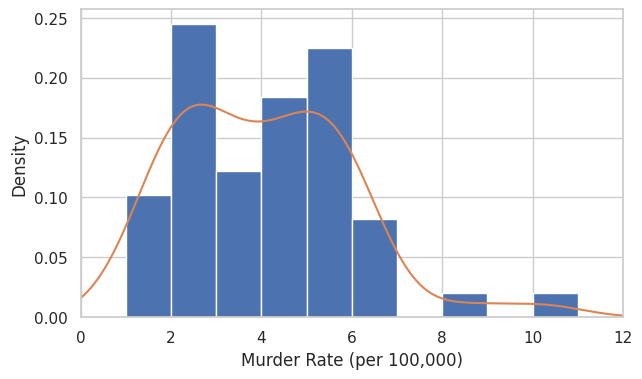

In [41]:
ax = state["Murder.Rate"].plot.hist(
    density=True,
    xlim=[0, 12],
    bins=range(1, 12),
    figsize=(7, 4)
)

state["Murder.Rate"].plot.density(ax=ax)

ax.set_xlabel("Murder Rate (per 100,000)")
ax.set_ylabel("Density")

plt.show()

### 11.1 Interpretasi Density Plot

Density plot menunjukkan bentuk distribusi Murder Rate secara kontinu.

Kurva yang lebih tinggi menunjukkan area dengan konsentrasi data yang
lebih besar.

Kurva membantu kita melihat bentuk distribusi dengan lebih halus
dibandingkan histogram.

Density plot juga dapat digunakan bersama histogram untuk mendapatkan
gambaran distribusi data secara lebih jelas.

## 11.2 Perbandingan Histogram dan Density Plot

Histogram dan density plot sama-sama digunakan untuk memahami distribusi
data.

Histogram:
- Menggunakan batang.
- Data dibagi menjadi bin.
- Sumbu Y dapat menunjukkan jumlah data atau proporsi.

Density plot:
- Menggunakan kurva kontinu.
- Tidak menampilkan frekuensi secara langsung.
- Menunjukkan bentuk distribusi yang lebih halus.

Keduanya dapat digunakan secara bersamaan untuk membantu memahami
distribusi suatu variabel.

# 12. Exploring Binary and Categorical Data

Data kategorikal adalah data yang terdiri dari sejumlah kategori tertentu.

Contoh data kategorikal:
- Jenis kelamin
- Jenis produk
- Status pelanggan
- Penyebab keterlambatan penerbangan

Binary data merupakan bentuk khusus dari data kategorikal yang hanya
memiliki dua kategori, misalnya:
- Ya / Tidak
- 0 / 1
- True / False

Untuk data kategorikal, ringkasan yang umum digunakan adalah proporsi
atau persentase setiap kategori.

Data kategorikal juga dapat divisualisasikan menggunakan bar chart.

## 12.1 Mode

Mode adalah kategori atau nilai yang paling sering muncul dalam suatu
dataset.

Berbeda dengan mean dan median, mode sangat berguna untuk data
kategorikal karena kategori tidak harus memiliki nilai numerik.

Jika terdapat lebih dari satu kategori dengan frekuensi tertinggi,
maka dataset dapat memiliki lebih dari satu mode.

In [42]:
state["State"].mode()

,State
0,Alabama
1,Alaska
2,Arizona
3,Arkansas
4,California
5,Colorado
6,Connecticut
7,Delaware
8,Florida
9,Georgia


## 12.2 Mengubah Data Numerik Menjadi Data Kategorikal

Data numerik dapat dikelompokkan menjadi beberapa kategori.

Pada contoh ini, Population akan dibagi menjadi tiga kategori:

- Kecil
- Sedang
- Besar

Pengelompokan seperti ini membuat data numerik lebih mudah diringkas
sebagai data kategorikal.

In [43]:
population_category = pd.cut(
    state["Population"],
    bins=[0, 5_000_000, 10_000_000, float("inf")],
    labels=["Kecil", "Sedang", "Besar"]
)

population_category.value_counts()

,count
Population,
Kecil,28
Sedang,15
Besar,7


cari mode

In [44]:
population_category.mode()

,Population
0,Kecil


### Interpretasi Mode

Mode menunjukkan kategori Population yang paling sering muncul.

Pada data yang telah dikelompokkan, kategori dengan frekuensi terbesar
merupakan mode.

Mode sangat berguna untuk data kategorikal karena kita tidak perlu
menghitung rata-rata dari kategori tersebut.

# 13. Expected Value

Expected value atau nilai harapan adalah rata-rata tertimbang
berdasarkan probabilitas terjadinya setiap kategori atau hasil.

Secara sederhana:

Expected Value = Σ (nilai × probabilitas)

Untuk menghitung expected value:

1. Kalikan setiap kemungkinan nilai dengan probabilitasnya.
2. Jumlahkan seluruh hasil perkalian tersebut.

Expected value dapat dipandang sebagai bentuk weighted mean, dengan
probabilitas sebagai bobot.

Expected Value

In [45]:
values = np.array([300, 50, 0])
probabilities = np.array([0.05, 0.15, 0.80])

expected_value = np.sum(values * probabilities)

expected_value

np.float64(22.5)

In [46]:
calculation = values * probabilities

print("Hasil perkalian:")
print(calculation)

print("\nExpected Value:")
print(calculation.sum())

Hasil perkalian:
[15.   7.5  0. ]

Expected Value:
22.5


### 13.1 Interpretasi Expected Value

Expected value yang diperoleh adalah 22,5.

Artinya, jika peluang pada contoh tersebut digunakan sebagai bobot,
rata-rata nilai yang diharapkan dari satu peserta webinar adalah $22,50
per bulan.

Expected value tidak berarti bahwa setiap peserta akan menghasilkan
tepat $22,50. Nilai tersebut merupakan rata-rata tertimbang berdasarkan
probabilitas setiap kemungkinan hasil.

# 14. Probability

Probability atau probabilitas menunjukkan kemungkinan suatu kejadian
terjadi.

Dalam konteks praktis, probabilitas dapat dipahami sebagai proporsi
kemunculan suatu kejadian jika situasi yang sama dapat diulang
berkali-kali.

Probabilitas memiliki nilai antara 0 dan 1:

- 0 berarti kejadian tidak terjadi.
- 1 berarti kejadian pasti terjadi.
- Nilai di antara 0 dan 1 menunjukkan tingkat kemungkinan terjadinya
  suatu kejadian.

In [47]:
population_category.value_counts(normalize=True)

,proportion
Population,
Kecil,0.56
Sedang,0.30
Besar,0.14


ubah menjadi persen

In [48]:
population_category.value_counts(normalize=True) * 100

,proportion
Population,
Kecil,56.0
Sedang,30.0
Besar,14.0


### 14.1 Interpretasi Probability

Proporsi setiap kategori dapat digunakan sebagai probabilitas empiris.

Sebagai contoh, jika suatu kategori memiliki proporsi 0,70, maka
probabilitas empiris berdasarkan dataset tersebut adalah 70%.

Probabilitas ini diperoleh dari frekuensi kategori dibandingkan dengan
jumlah seluruh observasi.

# 15. Bar Chart

Bar chart adalah grafik yang digunakan untuk menampilkan frekuensi atau
proporsi dari setiap kategori.

Pada bar chart:

- Sumbu X menunjukkan kategori.
- Sumbu Y menunjukkan frekuensi atau proporsi.
- Setiap kategori ditampilkan sebagai batang.

Bar chart terlihat mirip dengan histogram, tetapi keduanya memiliki
fungsi yang berbeda.

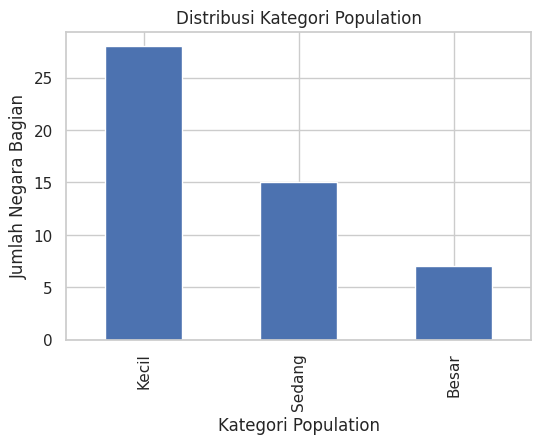

In [49]:
category_counts = population_category.value_counts()

ax = category_counts.plot.bar(figsize=(6, 4))

ax.set_xlabel("Kategori Population")
ax.set_ylabel("Jumlah Negara Bagian")
ax.set_title("Distribusi Kategori Population")

plt.show()

### Interpretasi Bar Chart

Bar chart menunjukkan jumlah negara bagian pada setiap kategori
Population.

Batang yang paling tinggi menunjukkan kategori dengan jumlah observasi
terbesar.

Berbeda dengan histogram, kategori pada bar chart merupakan kategori
yang terpisah, sehingga batang biasanya memiliki jarak satu sama lain.

## 15.1 Perbedaan Histogram dan Bar Chart

| Histogram | Bar Chart |
|---|---|
| Digunakan untuk data numerik | Digunakan untuk data kategorikal |
| Sumbu X berupa nilai atau interval numerik | Sumbu X berupa kategori |
| Data dikelompokkan dalam bin | Data dikelompokkan berdasarkan kategori |
| Batang biasanya berdempetan | Batang biasanya memiliki jarak |
| Menunjukkan distribusi numerik | Menunjukkan frekuensi atau proporsi kategori |

Walaupun bentuk visualnya mirip, histogram dan bar chart digunakan
untuk jenis data yang berbeda.

#16. Ringkasan Binary dan Categorical Data

Pada bagian ini telah dipelajari:

1. Mode
   Digunakan untuk menemukan kategori atau nilai yang paling sering
   muncul.

2. Expected Value
   Merupakan rata-rata tertimbang berdasarkan probabilitas setiap
   kemungkinan hasil.

3. Probability
   Menunjukkan kemungkinan atau proporsi suatu kejadian.

4. Bar Chart
   Digunakan untuk memvisualisasikan frekuensi atau proporsi data
   kategorikal.

Data kategorikal umumnya lebih tepat diringkas menggunakan frekuensi,
proporsi, persentase, dan mode daripada menggunakan ukuran seperti
mean.

# 17. Correlation

Correlation digunakan untuk melihat hubungan atau keterkaitan antara dua variabel numerik.

Dua variabel dikatakan memiliki korelasi positif jika nilai yang tinggi pada variabel pertama cenderung berhubungan dengan nilai yang tinggi pada variabel kedua.

Sebaliknya, korelasi negatif terjadi jika nilai yang tinggi pada satu variabel cenderung berhubungan dengan nilai yang rendah pada variabel lainnya.

Dalam Exploratory Data Analysis (EDA), korelasi dapat digunakan untuk mengetahui apakah terdapat hubungan antara variabel-variabel dalam dataset.

## 17.1 Correlation Coefficient

Correlation coefficient atau koefisien korelasi adalah ukuran yang digunakan untuk mengetahui seberapa kuat hubungan antara dua variabel numerik.

Koefisien korelasi Pearson memiliki rentang nilai dari -1 sampai +1.

- +1 → korelasi positif sempurna
- 0 → tidak terdapat korelasi linear
- -1 → korelasi negatif sempurna

Semakin mendekati +1, hubungan positif semakin kuat.

Semakin mendekati -1, hubungan negatif semakin kuat.

Nilai yang mendekati 0 menunjukkan hubungan linear yang semakin lemah.

Namun, korelasi tidak selalu berarti hubungan sebab-akibat (causation). Dua variabel yang berkorelasi belum tentu salah satunya menyebabkan perubahan pada variabel lainnya.

## 17.2 Menghitung Korelasi

In [50]:
state[['Population', 'Murder.Rate']].corr()

,Population,Murder.Rate
Population,1.000000,0.182069
Murder.Rate,0.182069,1.000000


## 17.3 Correlation Matrix

Correlation matrix adalah tabel yang menampilkan nilai korelasi antara beberapa variabel.

Variabel ditampilkan pada baris dan kolom. Setiap sel menunjukkan nilai korelasi antara pasangan variabel tersebut.

Nilai diagonal correlation matrix selalu bernilai 1 karena setiap variabel memiliki hubungan sempurna dengan dirinya sendiri.

Correlation matrix membantu kita melihat hubungan antar banyak variabel secara bersamaan.

## 17.4 Contoh Correlation Matrix

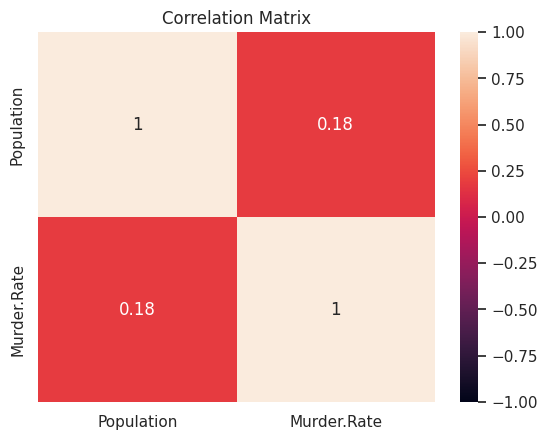

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = state[['Population', 'Murder.Rate']].corr()

sns.heatmap(
    corr,
    annot=True,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

# 18. Scatterplots

Scatterplot adalah grafik yang digunakan untuk memvisualisasikan hubungan antara dua variabel numerik.

Sumbu x menunjukkan nilai dari variabel pertama, sedangkan sumbu y menunjukkan nilai dari variabel kedua.

Setiap titik pada grafik mewakili satu observasi atau record.

## 18.1 Scatterplot ATT dan Verizon

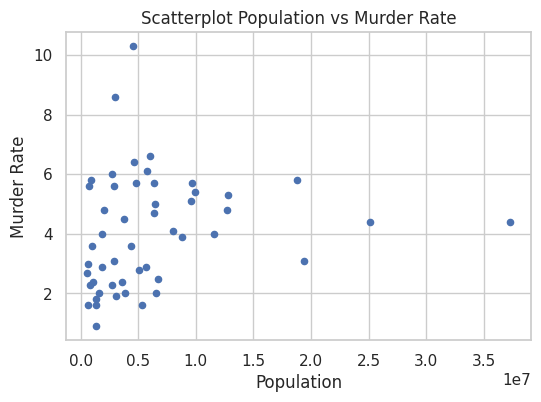

In [54]:
ax = state.plot.scatter(
    x='Population',
    y='Murder.Rate',
    figsize=(6, 4)
)

ax.set_xlabel('Population')
ax.set_ylabel('Murder Rate')
ax.set_title('Scatterplot Population vs Murder Rate')

plt.show()

### Interpretasi

Scatterplot digunakan untuk melihat pola hubungan antara Population dan Murder.Rate.

Setiap titik mewakili satu negara bagian. Posisi titik menunjukkan nilai Population pada sumbu x dan Murder.Rate pada sumbu y.

Dari scatterplot, kita dapat mengamati apakah terdapat pola hubungan positif, negatif, atau tidak ada pola yang jelas antara kedua variabel.

Scatterplot juga membantu mendeteksi adanya outlier atau observasi yang memiliki nilai jauh berbeda dari sebagian besar data.

# 19. Exploring Two or More Variables

Analisis sebelumnya seperti mean, variance, dan histogram umumnya digunakan untuk melihat satu variabel.

Ketika kita ingin melihat hubungan antara dua atau lebih variabel, kita membutuhkan metode yang berbeda.

Pada bagian ini dibahas beberapa metode untuk melakukan analisis dua atau lebih variabel, yaitu:

- Hexagonal binning
- Contour plot
- Contingency table
- Boxplot dan violin plot untuk data numerik dan kategorikal
- Visualisasi beberapa variabel sekaligus

Pemilihan metode visualisasi bergantung pada jenis variabel yang digunakan, misalnya numeric dengan numeric atau categorical dengan numeric.

## 19.1 Hexagonal Binning

Scatterplot bekerja dengan baik ketika jumlah data tidak terlalu banyak.

Namun, ketika dataset memiliki ratusan ribu atau jutaan record, scatterplot dapat menjadi terlalu padat sehingga titik-titik sulit dibedakan.

Hexagonal binning mengatasi masalah tersebut dengan membagi area grafik menjadi beberapa bagian berbentuk hexagon.

Setiap hexagon menunjukkan jumlah record yang terdapat pada area tersebut.

Dengan demikian, hexagonal binning dapat membantu melihat pola dan kepadatan data pada dataset yang besar.

In [59]:
import pandas as pd

kc_tax = pd.read_csv('/content/kc_tax.csv')

kc_tax.head()

,TaxAssessedValue,SqFtTotLiving,ZipCode
0,NaN,1730,98117.0
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0


In [60]:
kc_tax0 = kc_tax.loc[
    (kc_tax.TaxAssessedValue < 750000) &
    (kc_tax.SqFtTotLiving > 100) &
    (kc_tax.SqFtTotLiving < 3500),
    :
]

kc_tax0.shape

(432693, 3)

### Hexagonal Binning

Scatterplot dapat menjadi sulit dibaca ketika jumlah data sangat besar karena banyak titik yang saling bertumpuk.

Hexagonal binning mengatasi masalah tersebut dengan membagi area grafik menjadi beberapa bagian berbentuk heksagon. Setiap heksagon menunjukkan jumlah data yang berada pada area tersebut.

Dengan demikian, hexagonal binning membantu melihat pola dan kepadatan data pada dataset berukuran besar.

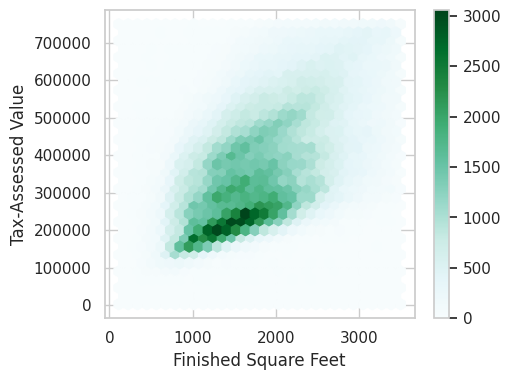

In [61]:
ax = kc_tax0.plot.hexbin(
    x='SqFtTotLiving',
    y='TaxAssessedValue',
    gridsize=30,
    sharex=False,
    figsize=(5, 4)
)

ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

plt.show()

### Interpretasi

Grafik hexagonal binning menunjukkan hubungan antara luas bangunan
(Finished Square Feet) dan nilai taksiran pajak (Tax-Assessed Value).

Grafik ini digunakan karena jumlah data sangat besar sehingga
scatterplot biasa dapat menghasilkan titik yang saling bertumpuk.
Dengan hexagonal binning, kepadatan data pada setiap area dapat
diamati dengan lebih jelas.

Secara umum, terlihat bahwa properti dengan luas bangunan yang lebih
besar cenderung memiliki nilai taksiran pajak yang lebih tinggi.

## 19.2 Contours

Selain menggunakan hexagonal binning, hubungan antara dua variabel
numerik juga dapat divisualisasikan menggunakan contour plot.

Contour plot menunjukkan kepadatan data melalui garis-garis kontur.
Area dengan garis kontur yang lebih rapat menunjukkan konsentrasi
data yang lebih tinggi.

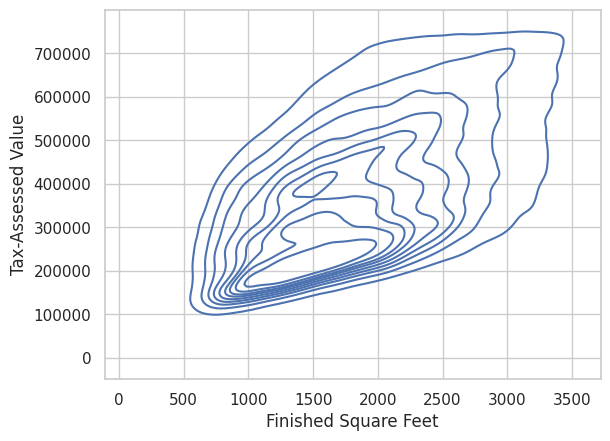

In [62]:
ax = sns.kdeplot(
    x=kc_tax0.SqFtTotLiving,
    y=kc_tax0.TaxAssessedValue
)

ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')

plt.show()

### Interpretasi

Contour plot memberikan gambaran mengenai konsentrasi atau kepadatan
data antara luas bangunan dan nilai taksiran pajak.

Area dengan konsentrasi data yang lebih tinggi ditunjukkan oleh
kontur yang lebih terkonsentrasi. Visualisasi ini membantu melihat
pola hubungan dua variabel numerik ketika jumlah data sangat besar.

# 20. Two Categorical Variables

Ketika dua variabel yang dianalisis merupakan variabel kategorikal,
hubungannya dapat ditampilkan menggunakan contingency table.

Contingency table menunjukkan jumlah observasi yang termasuk dalam
kombinasi kategori dari dua variabel.

load dataset

In [63]:
lc_loans = pd.read_csv(
    'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/lc_loans.csv'
)

lc_loans.head()

,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B


contingency table

In [64]:
crosstab = lc_loans.pivot_table(
    index='grade',
    columns='status',
    aggfunc=lambda x: len(x),
    margins=True
)

crosstab

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


Mengubah menjadi persentase

In [65]:
df = crosstab.loc['A':'G', :].copy()

df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(
    df['All'],
    axis=0
)

df['All'] = df['All'] / sum(df['All'])

perc_crosstab = df

perc_crosstab

/tmp/ipykernel_3881/838675109.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0215478  0.04005439 0.04982834 0.06740983 0.08165728 0.1182579
 0.12619562]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(
/tmp/ipykernel_3881/838675109.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.69045386 0.70901262 0.73570217 0.71732838 0.70793587 0.65437074
 0.61400802]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(
/tmp/ipykernel_3881/838675109.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.28152849 0.23540077 0.19149535 0.18418891 0.17092863 0

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,0.021548,0.690454,0.281528,0.006470,0.160746
B,0.040054,0.709013,0.235401,0.015532,0.293529
C,0.049828,0.735702,0.191495,0.022974,0.268039
D,0.067410,0.717328,0.184189,0.031073,0.164708
E,0.081657,0.707936,0.170929,0.039478,0.077177
F,0.118258,0.654371,0.180409,0.046962,0.028614
G,0.126196,0.614008,0.198396,0.061401,0.007187


### 20.1 Interpretasi

Contingency table digunakan untuk melihat hubungan antara dua variabel
kategorikal, yaitu grade dan status pinjaman.

Setiap baris menunjukkan kategori grade pinjaman, sedangkan kolom
menunjukkan status pinjaman. Nilai pada tabel menunjukkan proporsi
atau persentase pinjaman yang berada pada masing-masing status.

Dengan tabel ini, distribusi status pinjaman dapat dibandingkan
untuk setiap kategori grade.

#21. Categorical and Numeric Data

Ketika satu variabel bersifat kategorikal dan variabel lainnya
bersifat numerik, hubungan keduanya dapat divisualisasikan
menggunakan boxplot.

Boxplot membantu membandingkan distribusi nilai numerik pada setiap
kategori.

load dataset

In [66]:
airline_stats = pd.read_csv(
    'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/airline_stats.csv'
)

airline_stats.head()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


boxplot

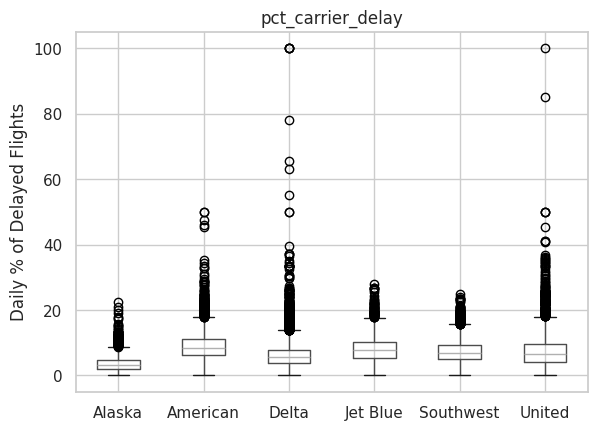

In [67]:
ax = airline_stats.boxplot(
    by='airline',
    column='pct_carrier_delay'
)

ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

plt.suptitle('')

plt.show()

### 21.1 Interpretasi

Boxplot digunakan untuk membandingkan persentase keterlambatan
penerbangan antar maskapai.

Setiap box menunjukkan distribusi persentase penerbangan yang
mengalami keterlambatan pada suatu maskapai. Boxplot juga membantu
melihat median, penyebaran data, dan kemungkinan nilai pencilan
(outlier).

# 22. Visualizing Multiple Variables

Visualisasi yang digunakan untuk membandingkan dua variabel seperti
scatterplot, hexagonal binning, dan boxplot dapat diperluas untuk
menganalisis lebih dari dua variabel.

Salah satu caranya adalah menggunakan konsep conditioning.

Conditioning berarti membagi data berdasarkan suatu variabel tertentu,
kemudian membuat visualisasi untuk setiap kelompok.

Pada contoh ini, hubungan antara luas bangunan
(SqFtTotLiving) dan nilai taksiran pajak (TaxAssessedValue)
dianalisis berdasarkan lokasi yang direpresentasikan oleh ZipCode.

Dengan membagi data berdasarkan ZipCode, pola hubungan antarvariabel
dapat dilihat dengan lebih jelas.

## 22.1 Memilih ZIP Code

In [68]:
zip_codes = [98188, 98105, 98108, 98126]

kc_tax_zip = kc_tax0.loc[
    kc_tax0.ZipCode.isin(zip_codes),
    :
]

kc_tax_zip

,TaxAssessedValue,SqFtTotLiving,ZipCode
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0
10,202000.0,830,98108.0
11,210000.0,1130,98108.0
12,193000.0,1560,98108.0
...,...,...,...
498049,346000.0,1430,98105.0
498050,463000.0,1610,98105.0
498051,553000.0,1580,98105.0
498052,571000.0,1840,98105.0


## 22.2 Membuat fungsi hexbin

In [70]:
def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(
        x,
        y,
        gridsize=25,
        cmap=cmap,
        **kwargs
    )

## 22.4 Membuat FacetGrid

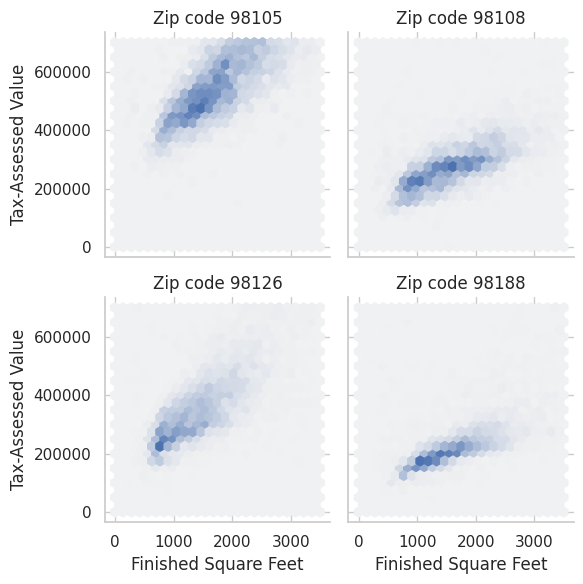

In [71]:
g = sns.FacetGrid(
    kc_tax_zip,
    col='ZipCode',
    col_wrap=2
)

g.map(
    hexbin,
    'SqFtTotLiving',
    'TaxAssessedValue',
    extent=[0, 3500, 0, 700000]
)

g.set_axis_labels(
    'Finished Square Feet',
    'Tax-Assessed Value'
)

g.set_titles(
    'Zip code {col_name:.0f}'
)

### Interpretasi

Visualisasi menunjukkan hubungan antara luas bangunan
(Finished Square Feet) dan nilai taksiran pajak
(Tax-Assessed Value) untuk beberapa ZIP code.

Dengan menggunakan ZIP code sebagai conditioning variable,
distribusi data dapat dibandingkan antarwilayah.

Terlihat bahwa pola dan tingkat nilai taksiran pajak berbeda
di antara ZIP code. Hal ini menunjukkan bahwa lokasi merupakan
salah satu faktor yang berkaitan dengan perbedaan nilai properti.

Pengelompokan berdasarkan ZIP code juga membantu menjelaskan
kelompok data yang terlihat pada visualisasi sebelumnya.

### Kesimpulan Visualizing Multiple Variables

Visualizing multiple variables memungkinkan hubungan antarvariabel
dianalisis dengan mempertimbangkan variabel tambahan.

Konsep conditioning dapat digunakan untuk membagi data menjadi
beberapa kelompok berdasarkan variabel tertentu.

Pada contoh ini, data properti dibagi berdasarkan ZipCode.
Dengan demikian, hubungan antara luas bangunan dan nilai taksiran
pajak dapat dibandingkan untuk beberapa wilayah secara terpisah.

Pendekatan ini membantu menemukan pola yang mungkin tidak terlihat
ketika seluruh data digabungkan dalam satu grafik.

## 23. Further Reading

Beberapa referensi yang direkomendasikan untuk mempelajari
visualisasi data lebih lanjut adalah:

1. *Modern Data Science with R* oleh Benjamin Baumer,
   Daniel Kaplan, dan Nicholas Horton (2017).
   Buku ini membahas konsep "grammar for graphics" yang menjadi
   dasar dari ggplot.

2. *ggplot2: Elegant Graphics for Data Analysis* oleh Hadley Wickham
   (2009). Buku ini merupakan referensi mengenai ggplot2,
   sebuah library visualisasi data dalam R.

3. Josef Fruehwald menyediakan tutorial berbasis web mengenai
   ggplot2.

## 24. Summary

Exploratory Data Analysis (EDA) yang dipelopori oleh John Tukey
menjadi salah satu dasar penting dalam bidang data science.

Ide utama dari EDA adalah bahwa langkah pertama dan paling penting
dalam proyek yang menggunakan data adalah melihat dan memahami data
tersebut.

Data dapat dipahami dengan cara merangkum dan memvisualisasikannya.
Melalui proses tersebut, kita dapat memperoleh intuisi dan
pemahaman mengenai karakteristik serta pola yang terdapat dalam data.

Pada chapter ini telah dibahas berbagai konsep, mulai dari metrik
sederhana seperti estimates of location dan estimates of variability,
hingga visualisasi yang digunakan untuk mengeksplorasi hubungan
antara beberapa variabel.

Berbagai tools dan teknik yang tersedia dalam komunitas open source,
serta kemampuan bahasa pemrograman seperti R dan Python, menyediakan
banyak cara untuk melakukan eksplorasi dan analisis data.

Oleh karena itu, exploratory analysis merupakan bagian penting
dalam setiap proyek data science.

# Key Ideas - Chapter 1

### 1. Exploratory Data Analysis (EDA)
EDA adalah proses awal untuk memahami data melalui peringkasan
statistik dan visualisasi.

### 2. Structured Data
Data dapat berbentuk terstruktur, salah satunya rectangular data
yang terdiri dari baris dan kolom.

### 3. Estimates of Location
Digunakan untuk mengetahui posisi pusat data, seperti:
- Mean
- Median
- Trimmed mean
- Weighted mean
- Weighted median

### 4. Estimates of Variability
Digunakan untuk mengetahui seberapa menyebar data, seperti:
- Standard deviation
- Variance
- Mean absolute deviation
- Median absolute deviation
- Range
- Interquartile range (IQR)

### 5. Data Distribution
Distribusi data dapat dieksplorasi menggunakan:
- Frequency table
- Histogram
- Density plot
- Boxplot
- Percentiles

### 6. Binary and Categorical Data
Data kategorikal dapat dianalisis menggunakan:
- Mode
- Expected value
- Probability
- Bar chart

### 7. Correlation
Correlation digunakan untuk melihat hubungan linear antara dua
variabel numerik. Nilainya berada pada rentang -1 sampai +1.

### 8. Scatterplot
Scatterplot digunakan untuk melihat hubungan antara dua variabel
numerik.

### 9. Hexagonal Binning
Digunakan untuk melihat hubungan dua variabel numerik ketika jumlah
data sangat besar sehingga scatterplot menjadi terlalu padat.

### 10. Contingency Table
Digunakan untuk menganalisis jumlah atau proporsi dari dua variabel
kategorikal.

### 11. Boxplot
Digunakan untuk membandingkan distribusi variabel numerik
berdasarkan kategori.

### 12. Conditioning Variables
Data dapat dibagi berdasarkan variabel tertentu untuk melihat
hubungan antarvariabel pada kelompok yang berbeda.